## Imports

In [17]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import ROI as r
import Vis as vis
import CompVis as comp_vis
from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### variabels

In [2]:
nPC = 8
reduction_factor = 0.2
out_video_path = 'out/'
nframes = 800
fps = 240

## **Main: single video**

In [3]:
in_video_path = 'videos/8days/20260207/240/VID_20260207_081701560.mp4'
vf = func.video_status(in_video_path, verbose = True)

vpath: videos/8days/20260207/240/VID_20260207_081701560.mp4
fps: 30
width: 720
height: 1280
frames: 2586
duration: 86.2
mode: BGR
shape: (1280, 720, 3)
rotation: 270


### pre-processing

In [9]:
# r.roi_selection(in_video_path)
comp_vis.pre_processing(in_video_path, out_video_path + in_video_path.split('/')[-1], nframes, fps, reduction_factor, (25, 148, 631, 819))

### computer vision

In [4]:
unmixed = comp_vis.moses_code(out_video_path + in_video_path.split('/')[-1], nPC)
vf = func.video_status(out_video_path + in_video_path.split('/')[-1], verbose = False)

{0: 3.0,
 1: 1.7999999999999998,
 2: 0.6,
 3: 0.8999999999999999,
 4: 1.2,
 5: 1.7999999999999998,
 6: 1.5,
 7: 3.3}

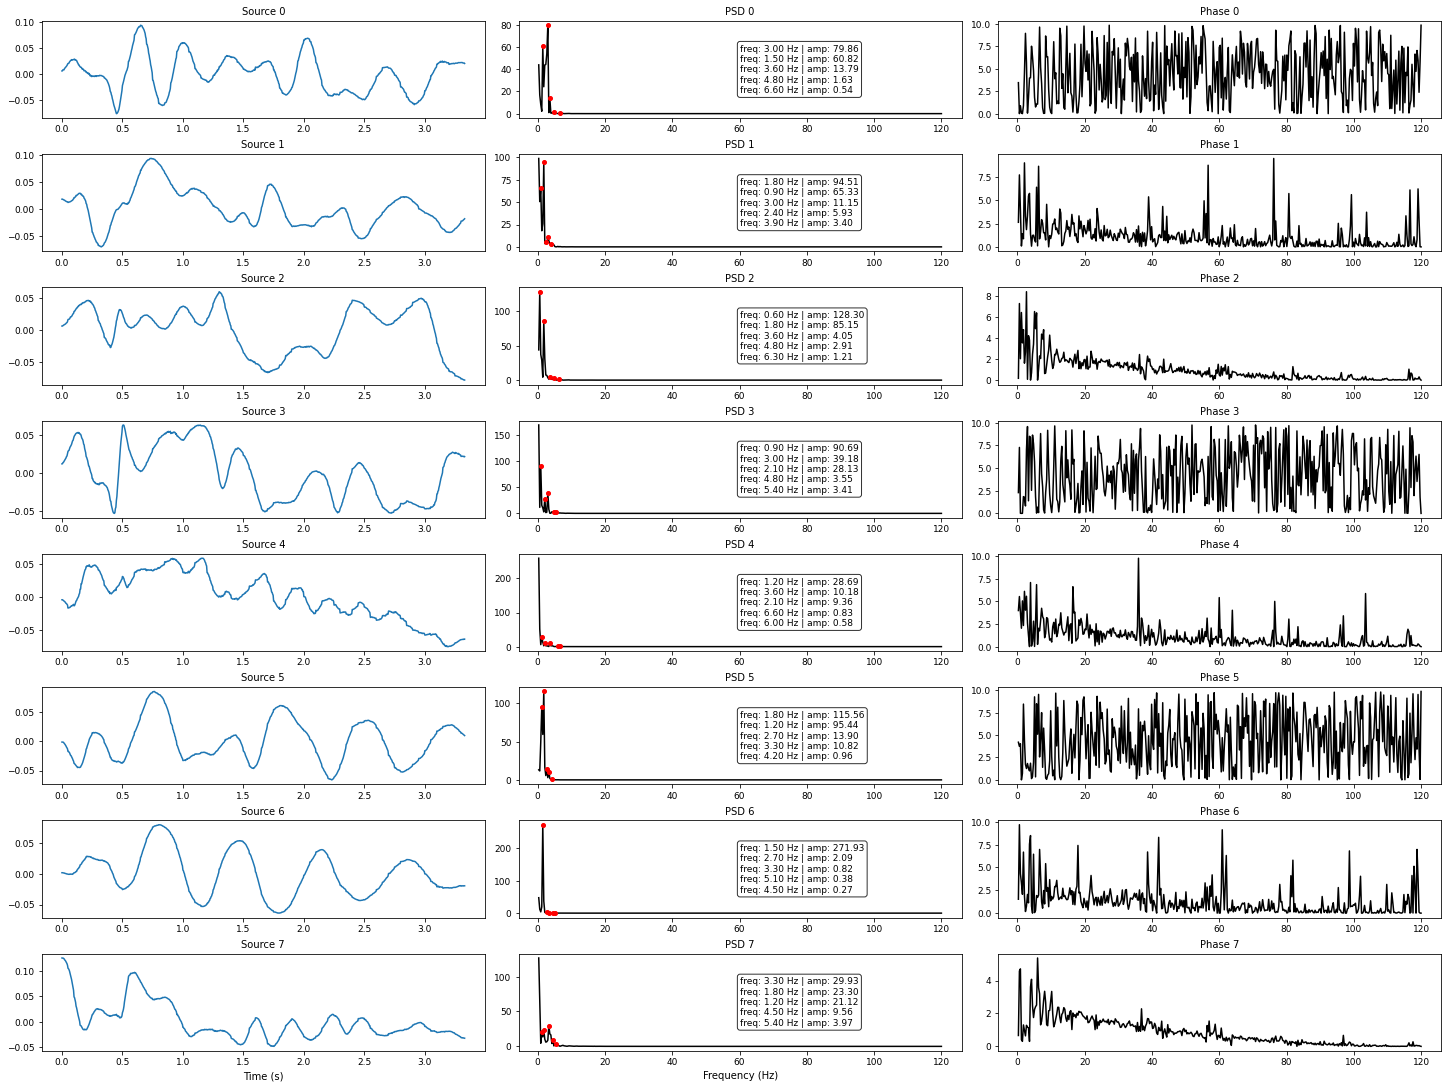

In [5]:
comp_vis.plot_pc(unmixed, vf, range(nPC), save = True)

{6: 1.5}

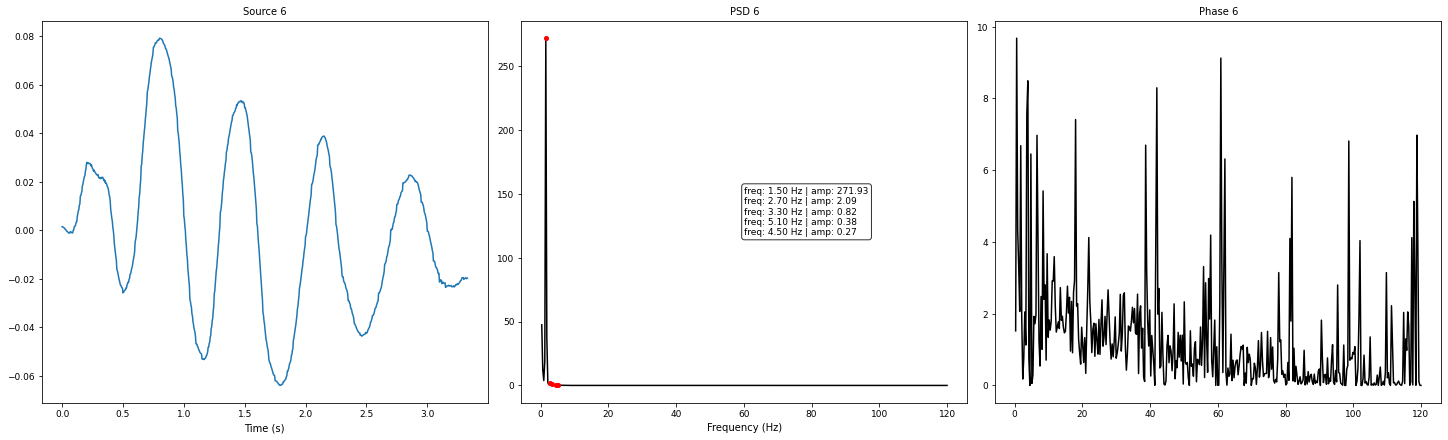

In [7]:
comp_vis.plot_pc(unmixed, vf, [6], w = 20, h = 6)

## **Main: variation over time**

In [8]:
names = ['videos/8days/20260207/240/VID_20260207_081701560.mp4', 
         'videos/8days/20260208/240/VID_20260208_071551134.mp4',
         'videos/8days/20260209/240/VID_20260209_075208490.mp4',
         'videos/8days/20260210/240/VID_20260210_073714886.mp4',
         'videos/8days/20260211/240/VID_20260211_072715346.mp4',
         'videos/8days/20260212/240/VID_20260212_072409310.mp4',
         'videos/8days/20260213/240/VID_20260213_073426768.mp4',
         'videos/8days/20260214/240/VID_20260214_040340493.mp4']

In [32]:
r.roi_selection(names[7])

In [9]:
rois = [(25, 148, 631, 819),
        (12, 169, 689, 814),
        (10, 132, 680, 823),
        (10, 89, 699, 851),
        (6, 125, 689, 804),
        (5, 146, 670, 785),
        (10, 120, 680, 830),
        (8, 112, 687, 800)]

In [10]:
for i, (name, roi) in enumerate(zip(names, rois)):
    print(f'{name} processing...', end = ' ')
    comp_vis.pre_processing(name, out_video_path + name.split('/')[-1], nframes, fps, reduction_factor, roi)
    print(f'done.')

videos/8days/20260207/240/VID_20260207_081701560.mp4 processing... done.
videos/8days/20260208/240/VID_20260208_071551134.mp4 processing... done.
videos/8days/20260209/240/VID_20260209_075208490.mp4 processing... done.
videos/8days/20260210/240/VID_20260210_073714886.mp4 processing... done.
videos/8days/20260211/240/VID_20260211_072715346.mp4 processing... done.
videos/8days/20260212/240/VID_20260212_072409310.mp4 processing... done.
videos/8days/20260213/240/VID_20260213_073426768.mp4 processing... done.
videos/8days/20260214/240/VID_20260214_040340493.mp4 processing... done.


In [ ]:
results = []
for name in names:
    video_file = 'out/' + name.split('/')[-1]
    unmixed = comp_vis.moses_code(video_file, nPC)
    
    vf = func.video_status(video_file, verbose = False)
    results.append(comp_vis.plot_pc(unmixed, vf, range(nPC), save = False))

In [12]:
results2 = {}

for d in results:
    for k, v in d.items():
        if k not in results2:
            results2[k] = []
        results2[k].append(v)

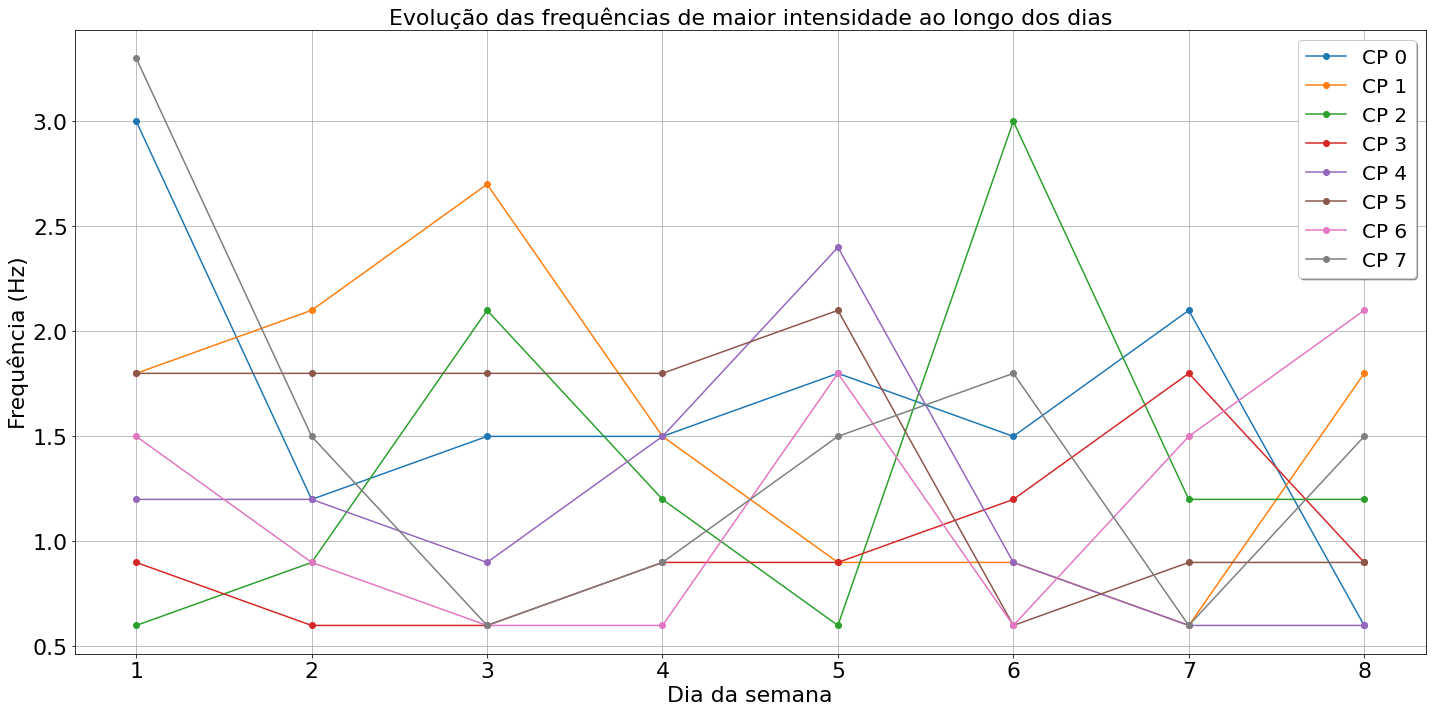

In [20]:
dias = list(range(1, 9))

plt.figure(figsize=(20, 10))

for componente, valores in results2.items():
    plt.plot(dias, valores, marker='o', label=f'CP {componente}')

plt.xlabel('Dia da semana', fontsize = 22)
plt.ylabel('Frequência (Hz)', fontsize = 22)
plt.title('Evolução das frequências de maior intensidade ao longo dos dias', fontsize = 22)
plt.xticks(dias)
plt.legend(loc = 'upper right', fancybox = True, shadow = True, fontsize = 20)
plt.tick_params(axis = 'both', labelsize = 22)
plt.grid(True)
plt.tight_layout()

In [14]:
results3 = list(map(lambda x: np.mean(list(x.values())), results))

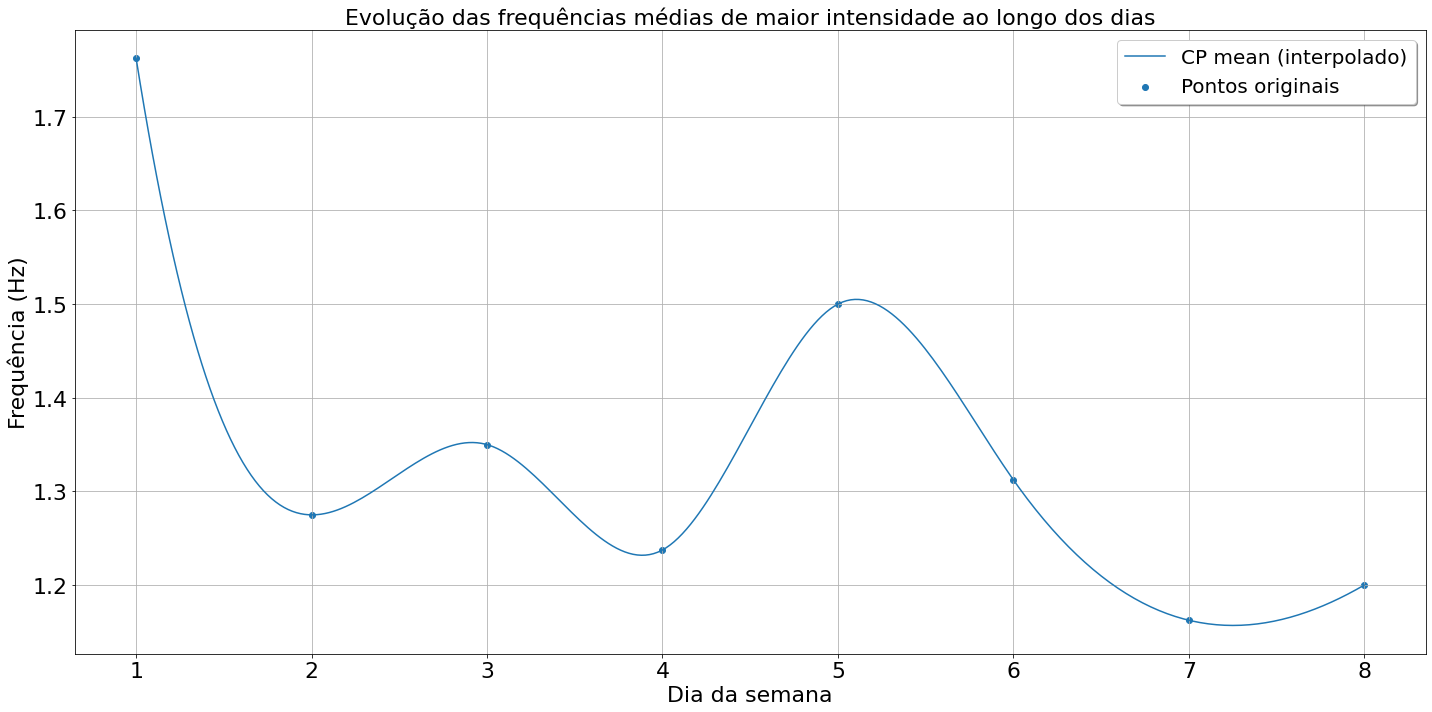

In [18]:
dias = np.array(list(range(1, 9)))
y = np.array(results3)

# cria novos pontos mais densos (suavização)
dias_smooth = np.linspace(dias.min(), dias.max(), 300)

# interpolação spline cúbica
spline = make_interp_spline(dias, y, k=3)
y_smooth = spline(dias_smooth)

plt.figure(figsize=(20, 10))

# curva suave
plt.plot(dias_smooth, y_smooth, label='CP mean (interpolado)')

# pontos originais
plt.scatter(dias, y, label='Pontos originais')

plt.xlabel('Dia da semana', fontsize=22)
plt.ylabel('Frequência (Hz)', fontsize=22)
plt.title('Evolução das frequências médias de maior intensidade ao longo dos dias', fontsize=22)
plt.xticks(dias)
plt.legend(loc='upper right', fancybox=True, shadow=True, fontsize=20)
plt.tick_params(axis='both', labelsize=22)
plt.grid(True)
plt.tight_layout()

plt.show()

### spectrogram

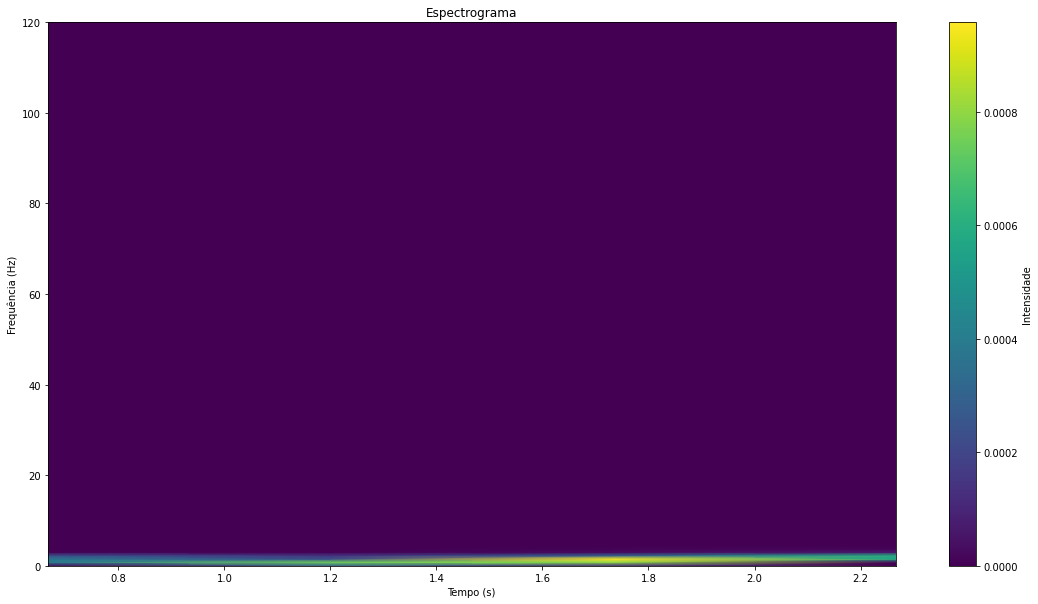

<Figure size 432x288 with 0 Axes>

In [21]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

fs = 240 # fps do vídeo

f, t, Sxx = spectrogram(
    unmixed[:, 1],
    fs=fs,
    window='hann',
    nperseg=320,
    noverlap=192
)
plt.figure(figsize = [19, 10])
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequência (Hz)")
plt.xlabel("Tempo (s)")
plt.title("Espectrograma")
plt.colorbar(label="Intensidade")
plt.show()
plt.savefig('out/spect.png', bbox_inches = 'tight')